<div style="background:linear-gradient(135deg,#431407 0%,#c2410c 55%,#fb923c 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#ffedd5;font-weight:700;text-transform:uppercase">Chapter 96 · Logistic Regression</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Logistic Regression</div>
  <div style="font-size:15px;color:#fff7ed;max-width:740px;line-height:1.6">Fit the S-curve by maximum likelihood, read odds ratios, draw the ROC, choose a threshold on the precision/recall trade-off, and cure class imbalance and perfect separation, library-first with statsmodels and scikit-learn.</div>
  <div style="margin-top:16px;font-size:13px;color:#ffedd5">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## Logistic regression: probabilities, odds ratios, and thresholds
Library-first with `statsmodels` (for inference and odds ratios) and `scikit-learn` (for metrics and the regularized fix). We fit the S-curve, read odds ratios, draw the ROC, walk the precision/recall trade-off, and break then repair the model with regularization.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, regplots, pairplots)
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
ORG="#ea580c"; DEEP="#c2410c"; LIGHT="#fdba74"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
import warnings; warnings.filterwarnings('ignore')
import statsmodels.formula.api as smf
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report, RocCurveDisplay

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">DEMO 1 &#183; STEPS 1&#8211;2</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Fit the S-curve</div>
<div style="color:#4a5578;margin-top:6px">Explore the binary outcome, then fit logistic regression by maximum likelihood.</div>
</div>

In [3]:
try:
    loans = pd.read_excel('../../data/ch96_loans.xlsx', sheet_name='Loans')
except FileNotFoundError:
    loans = pd.read_excel(BASE + 'ch96_loans.xlsx', sheet_name='Loans')
print(loans.shape, ' default rate = %.1f%%' % (100*loans.default.mean()))
loans.head(3)

(420, 5)  default rate = 29.3%


,loan_id,credit_score,dti,loan_amount,default
0,L3000,775,0.264,59154,0
1,L3001,749,0.397,52675,1
2,L3002,771,0.257,28225,0


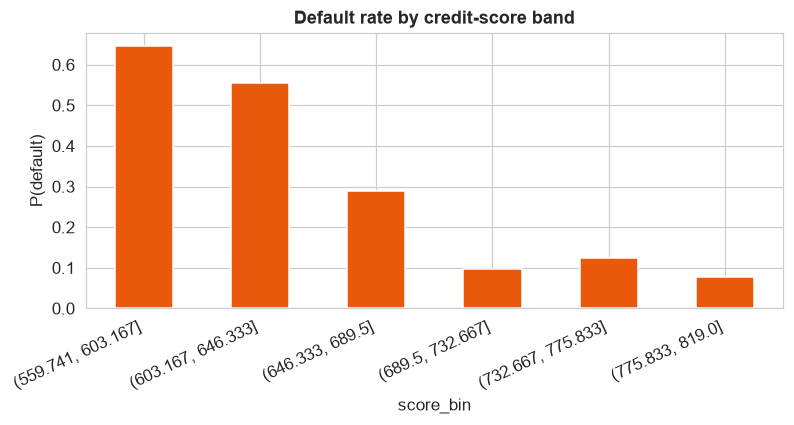

In [4]:
# EXPLORE FIRST: default rate really does fall with credit score
loans['score_bin'] = pd.cut(loans.credit_score, 6)
rate = loans.groupby('score_bin', observed=True).default.mean()
fig, ax = plt.subplots(figsize=(7.4,4)); rate.plot(kind='bar', color=ORG, ax=ax)
ax.set(title='Default rate by credit-score band', ylabel='P(default)'); plt.xticks(rotation=25, ha='right'); plt.tight_layout(); plt.show()

In [5]:
model = smf.logit('default ~ credit_score + dti + loan_amount', loans).fit(disp=0)
print(model.summary().tables[1])
print(f'\nMcFadden pseudo-R2 = {model.prsquared:.3f}')

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        9.3884      1.349      6.958      0.000       6.744      12.033
credit_score    -0.0183      0.002     -8.864      0.000      -0.022      -0.014
dti              5.0293      1.352      3.719      0.000       2.379       7.680
loan_amount   9.541e-06    7.9e-06      1.208      0.227   -5.93e-06     2.5e-05

McFadden pseudo-R2 = 0.240


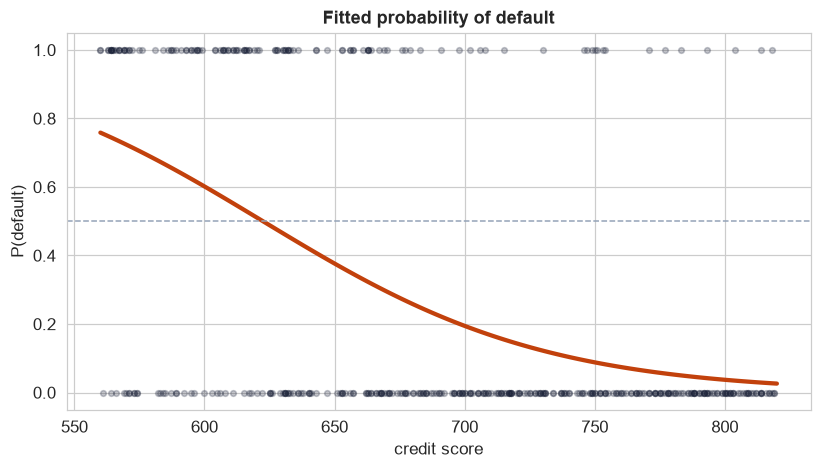

In [6]:
# The fitted S-curve vs credit score (other predictors at their means)
grid = pd.DataFrame({'credit_score': np.linspace(560,820,120), 'dti': loans.dti.mean(), 'loan_amount': loans.loan_amount.mean()})
fig, ax = plt.subplots(figsize=(7.6,4.4))
ax.scatter(loans.credit_score, loans.default, s=14, color=INK, alpha=0.25)
ax.plot(grid.credit_score, model.predict(grid), color=DEEP, lw=2.8)
ax.axhline(0.5, color=GREY, ls='--', lw=1)
ax.set(title='Fitted probability of default', xlabel='credit score', ylabel='P(default)'); plt.tight_layout(); plt.show()

<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#c2410c;letter-spacing:1px">DEMO 2 &#183; ODDS RATIOS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Coefficients become odds ratios</div>
<div style="color:#4a5578;margin-top:6px">Exponentiate to read each effect as a multiplier on the odds, with confidence intervals.</div>
</div>

In [7]:
OR = np.exp(model.params); ci = np.exp(model.conf_int())
tab = pd.DataFrame({'odds_ratio': OR.round(3), 'CI_low': ci[0].round(3), 'CI_high': ci[1].round(3)})
print(tab)
print(f"\nPer +50 credit points: OR = {np.exp(model.params['credit_score']*50):.2f}  (protective)")
print(f"Per +0.1 debt-to-income: OR = {np.exp(model.params['dti']*0.1):.2f}  (raises risk)")

              odds_ratio   CI_low     CI_high
Intercept      11948.881  848.942  168180.893
credit_score       0.982    0.978       0.986
dti              152.829   10.791    2164.520
loan_amount        1.000    1.000       1.000

Per +50 credit points: OR = 0.40  (protective)
Per +0.1 debt-to-income: OR = 1.65  (raises risk)


**Reading odds ratios.** A logistic coefficient is a change in log-odds, which is hard to feel, so we exponentiate it (e^coef) into an **odds ratio**, the factor by which the odds of default multiply per one-unit rise in the predictor:

- **OR = 1** means no effect.
- **OR < 1** is protective: credit score's OR per +50 points is about 0.40, so 50 more points cut the odds of default to 40% of what they were (a 60% reduction).
- **OR > 1** raises risk: debt-to-income's OR per +0.1 is about 1.65, so each 0.1 rise multiplies the odds by 1.65.

The confidence interval matters too: if an odds ratio's interval spans 1, the predictor earns no conclusion (loan amount here).

<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#c2410c;letter-spacing:1px">DEMO 3 &#183; STEP 5</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Threshold, confusion matrix, ROC</div>
<div style="color:#4a5578;margin-top:6px">The model gives probabilities; you pick the threshold. See the precision/recall trade-off and the ROC.</div>
</div>

In [8]:
p = model.predict(loans); auc = roc_auc_score(loans.default, p)
print(f'AUC = {auc:.3f}')
for t in (0.5, 0.3):
    yhat = (p >= t).astype(int)
    cm = confusion_matrix(loans.default, yhat)
    print(f'\n--- threshold {t} ---'); print(cm)
    print(classification_report(loans.default, yhat, digits=2, target_names=['repaid','default']))

AUC = 0.822

--- threshold 0.5 ---
[[269  28]
 [ 54  69]]
              precision    recall  f1-score   support

      repaid       0.83      0.91      0.87       297
     default       0.71      0.56      0.63       123

    accuracy                           0.80       420
   macro avg       0.77      0.73      0.75       420
weighted avg       0.80      0.80      0.80       420


--- threshold 0.3 ---
[[217  80]
 [ 31  92]]
              precision    recall  f1-score   support

      repaid       0.88      0.73      0.80       297
     default       0.53      0.75      0.62       123

    accuracy                           0.74       420
   macro avg       0.70      0.74      0.71       420
weighted avg       0.78      0.74      0.75       420



**Reading the confusion matrix and report.** At a given threshold the predictions fall into four cells: true negatives and true positives (correct), plus false positives (predicted default, actually repaid) and false negatives (missed defaults). From them:

- **accuracy** = fraction correct overall, misleading when the classes are imbalanced.
- **precision** = of the loans we flagged as defaults, how many really defaulted.
- **recall** = of the loans that really defaulted, how many we caught, usually the number a lender cares about most.
- **AUC** is threshold-free: it summarizes how well the model *ranks* risky loans above safe ones across every threshold.

Compare thresholds 0.5 and 0.3: dropping the cutoff raises recall (more defaults caught) at the cost of precision (more false alarms). There is no free lunch, only a business choice.

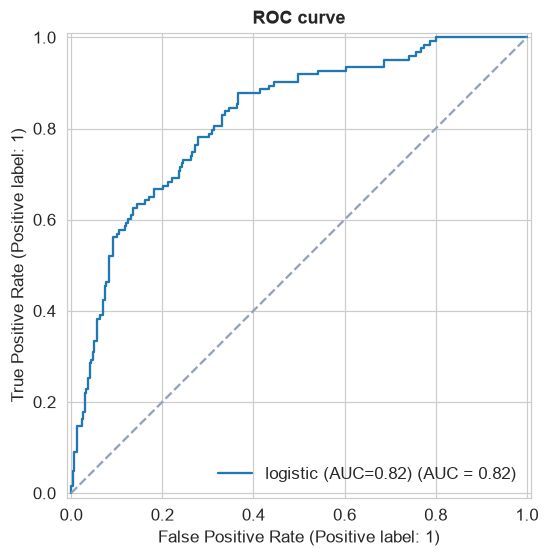

In [9]:
fig, ax = plt.subplots(figsize=(6.4,5.2))
RocCurveDisplay.from_predictions(loans.default, p, ax=ax, name=f'logistic (AUC={auc:.2f})')
ax.plot([0,1],[0,1], ls='--', color=GREY); ax.set_title('ROC curve'); plt.tight_layout(); plt.show()

<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#c2410c;letter-spacing:1px">DEMO 4 &#183; IMBALANCE &amp; THE FIX</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The accuracy paradox and a regularized cure for separation</div>
<div style="color:#4a5578;margin-top:6px">A do-nothing baseline looks accurate; class weights fix recall. Then we break the model with perfect separation and repair it.</div>
</div>

In [10]:
from sklearn.linear_model import LogisticRegression
acc_baseline = (loans.default==0).mean()
print(f'Predict-all-repaid accuracy = {acc_baseline:.2f}  (but recall on defaults = 0)')
X = loans[['credit_score','dti','loan_amount']]; y = loans.default
bal = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X, y)
from sklearn.metrics import recall_score
print(f'class_weight=balanced recall on defaults = {recall_score(y, bal.predict(X)):.2f}  (catches far more)')

Predict-all-repaid accuracy = 0.71  (but recall on defaults = 0)
class_weight=balanced recall on defaults = 0.78  (catches far more)


In [11]:
# PERFECT SEPARATION: a feature that perfectly splits the classes breaks maximum likelihood
sep = loans.copy(); sep['leak'] = sep['default']*10 + np.random.default_rng(0).normal(0,0.01,len(sep))
try:
    smf.logit('default ~ leak', sep).fit(disp=0, maxiter=100)
    print('statsmodels: converged (unexpected)')
except Exception as e:
    print('statsmodels MLE fails on separation:', type(e).__name__)
# scikit-learn is L2-penalized by default, so it stays finite
reg = LogisticRegression(max_iter=1000).fit(sep[['leak']], sep.default)
print(f'regularized logistic: finite coefficient = {reg.coef_[0][0]:.2f}  (no blow-up)')

statsmodels MLE fails on separation: LinAlgError
regularized logistic: finite coefficient = 1.43  (no blow-up)


## Putting it all together: the logistic workflow

The five-step workflow carries over to a yes/no outcome, with new tools at each step.

**Step 1, explore.** The default rate fell steadily with credit score, a strong, monotonic signal, and the classes were imbalanced (29% default), which we kept in mind for the threshold.

**Step 2, fit.** Logistic regression models the log-odds of default through the sigmoid and is fit by **maximum likelihood**, not least squares, because the outcome is binary.

**Step 3, evaluate.** We judged the model by **AUC** (0.82, how well it ranks risk) and **pseudo-R-squared** (0.24), not a single accuracy number.

**Odds ratios.** Exponentiating each coefficient gave an odds ratio: +50 credit points multiply the odds of default by 0.40 (protective), each +0.1 of debt-to-income by 1.65 (risky). An odds ratio whose interval spans 1 earns no conclusion.

**Steps 4-5, check conditions and decide.** Two logistic-specific hazards: **class imbalance** (why we judge by recall/AUC, not accuracy, a 'never default' model scores 71% accuracy while catching nothing) and **perfect separation** (a predictor that splits the classes sends maximum-likelihood coefficients to infinity; the cure is a **regularized/penalized** logistic regression, which stays finite). Finally the **threshold** turns the predicted probability into a decision: lowering it from 0.5 to 0.3 raised recall from 0.56 to 0.75 at the cost of precision, a trade-off only the business can set.

**Takeaway.** Logistic regression is a one-neuron classifier; its odds ratios, calibration, and threshold choice are the same concerns that govern every deployed classifier.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>